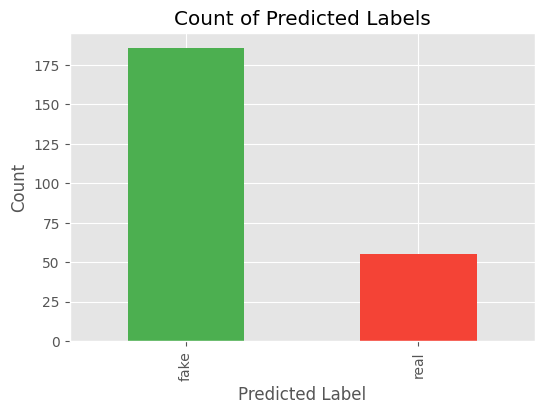

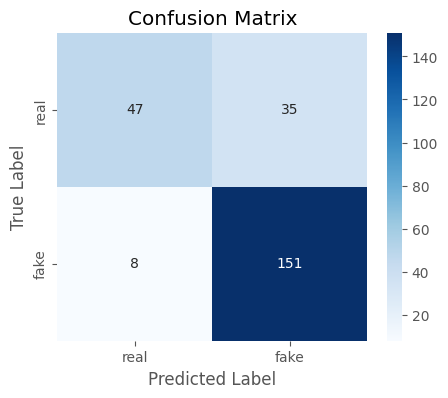

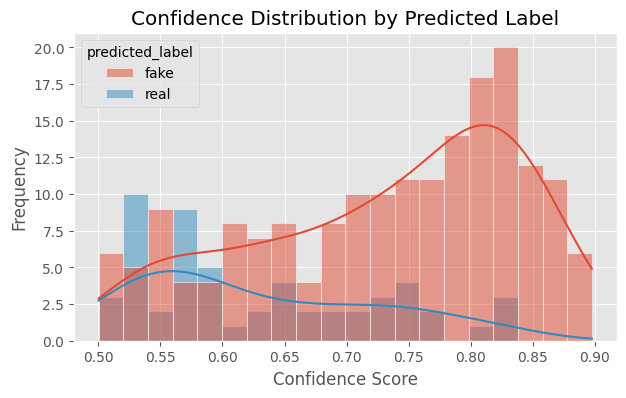

C:\Users\uzair\AppData\Local\Temp\ipykernel_22668\3872137067.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="correct", y="confidence", data=df, palette="Set2")


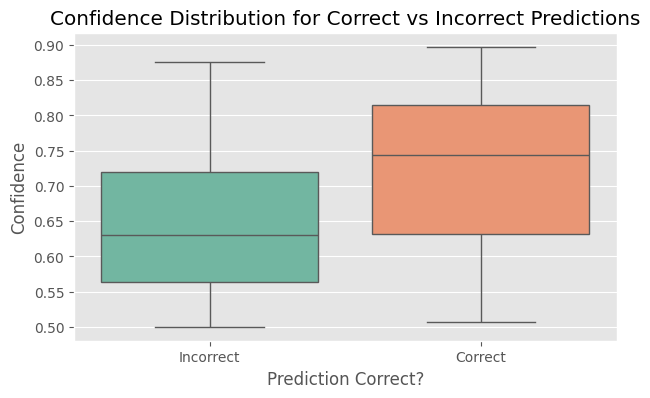

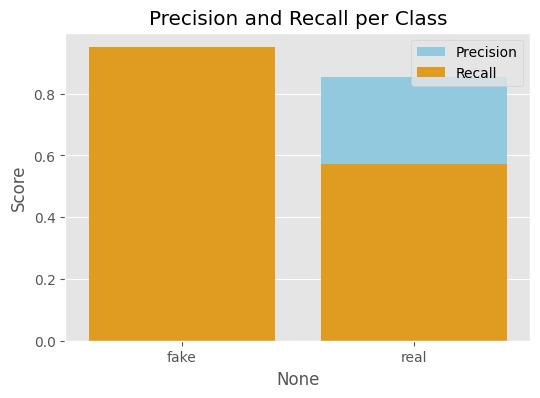

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Load your data
df = pd.read_csv("val_video_predictions.csv")

# Set style
plt.style.use("ggplot")

# 1️⃣ Bar Chart – Count of Predicted Labels
plt.figure(figsize=(6, 4))
df['predicted_label'].value_counts().plot(kind='bar', color=['#4caf50', '#f44336'])
plt.title("Count of Predicted Labels")
plt.xlabel("Predicted Label")
plt.ylabel("Count")
plt.show()

# 2️⃣ Confusion Matrix Heatmap
plt.figure(figsize=(5, 4))
cm = confusion_matrix(df['true_label'], df['predicted_label'], labels=["real", "fake"])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["real", "fake"], yticklabels=["real", "fake"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# 3️⃣ Confidence Distribution by Predicted Label
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="confidence", hue="predicted_label", bins=20, kde=True)
plt.title("Confidence Distribution by Predicted Label")
plt.xlabel("Confidence Score")
plt.ylabel("Frequency")
plt.show()

# 4️⃣ Confidence vs Correctness (Was prediction correct?)
df['correct'] = df['true_label'] == df['predicted_label']
plt.figure(figsize=(7, 4))
sns.boxplot(x="correct", y="confidence", data=df, palette="Set2")
plt.title("Confidence Distribution for Correct vs Incorrect Predictions")
plt.xlabel("Prediction Correct?")
plt.ylabel("Confidence")
plt.xticks([0, 1], ["Incorrect", "Correct"])
plt.show()

# 5️⃣ Per-Class Accuracy (Bar Plot)
report = classification_report(df['true_label'], df['predicted_label'], output_dict=True)
acc_df = pd.DataFrame(report).transpose().iloc[:2]  # Only real and fake
plt.figure(figsize=(6, 4))
sns.barplot(x=acc_df.index, y=acc_df["precision"], color="skyblue", label="Precision")
sns.barplot(x=acc_df.index, y=acc_df["recall"], color="orange", label="Recall")
plt.title("Precision and Recall per Class")
plt.ylabel("Score")
plt.legend()
plt.show()


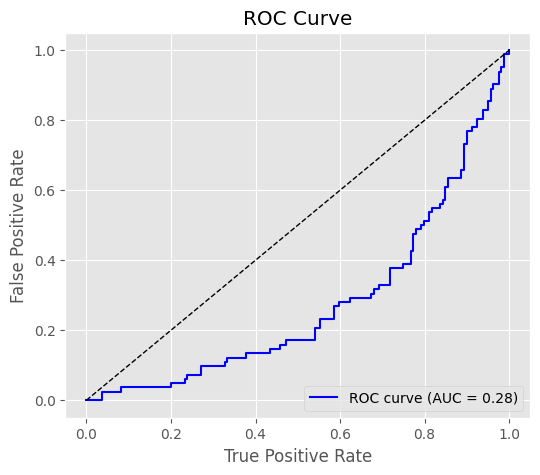

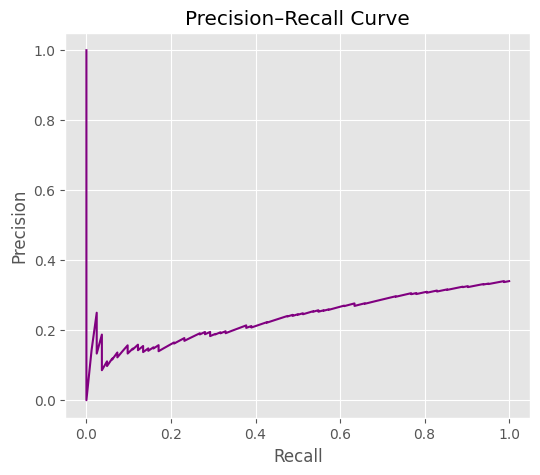

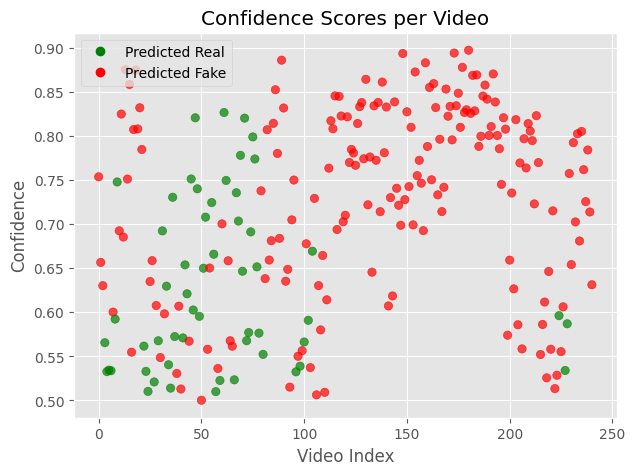

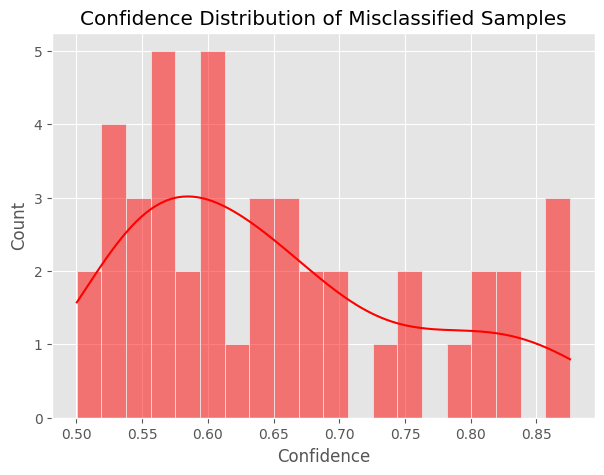

C:\Users\uzair\AppData\Local\Temp\ipykernel_12312\3818298312.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='true_label', y='confidence', data=df, palette=['green', 'red'])


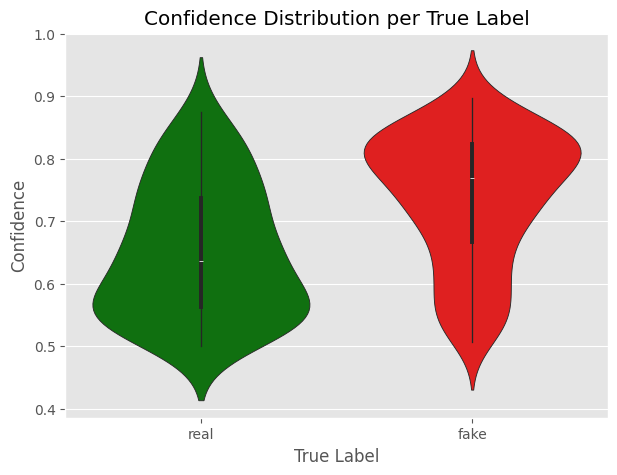

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve

df = pd.read_csv("val_video_predictions.csv")

# Convert true_label to binary for ROC & PR curve
df["true_binary"] = df["true_label"].map({"real": 1, "fake": 0})
df["pred_binary"] = df["predicted_label"].map({"real": 1, "fake": 0})

plt.style.use("ggplot")

# 6️⃣ ROC Curve
plt.figure(figsize=(6, 5))
fpr, tpr, _ = roc_curve(df["true_binary"], df["confidence"])
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})", color='blue')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel("True Positive Rate")
plt.ylabel("False Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

# 7️⃣ Precision–Recall Curve
plt.figure(figsize=(6, 5))
precision, recall, _ = precision_recall_curve(df["true_binary"], df["confidence"])
plt.plot(recall, precision, color='purple')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.show()

# 8️⃣ Confidence Scatter Plot (True vs Predicted)
plt.figure(figsize=(7, 5))
colors = df['predicted_label'].map({'real': 'green', 'fake': 'red'})
plt.scatter(range(len(df)), df['confidence'], c=colors, alpha=0.7)
plt.title("Confidence Scores per Video")
plt.xlabel("Video Index")
plt.ylabel("Confidence")
plt.legend(handles=[
    plt.Line2D([], [], color='green', marker='o', linestyle='', label='Predicted Real'),
    plt.Line2D([], [], color='red', marker='o', linestyle='', label='Predicted Fake')
])
plt.show()

# 9️⃣ Error Analysis (Confidence of Misclassified Samples)
df['correct'] = df['true_label'] == df['predicted_label']
plt.figure(figsize=(7, 5))
sns.histplot(df[df['correct'] == False]['confidence'], bins=20, color='red', kde=True)
plt.title("Confidence Distribution of Misclassified Samples")
plt.xlabel("Confidence")
plt.ylabel("Count")
plt.show()

# 🔟 Per-Video Confidence Comparison for Real vs Fake (Violin Plot)
plt.figure(figsize=(7, 5))
sns.violinplot(x='true_label', y='confidence', data=df, palette=['green', 'red'])
plt.title("Confidence Distribution per True Label")
plt.xlabel("True Label")
plt.ylabel("Confidence")
plt.show()


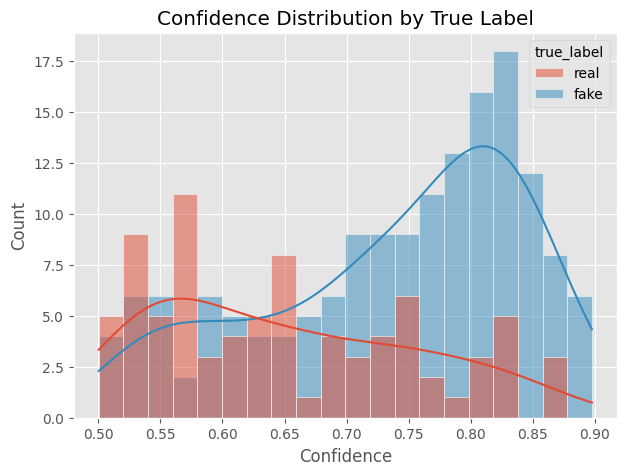

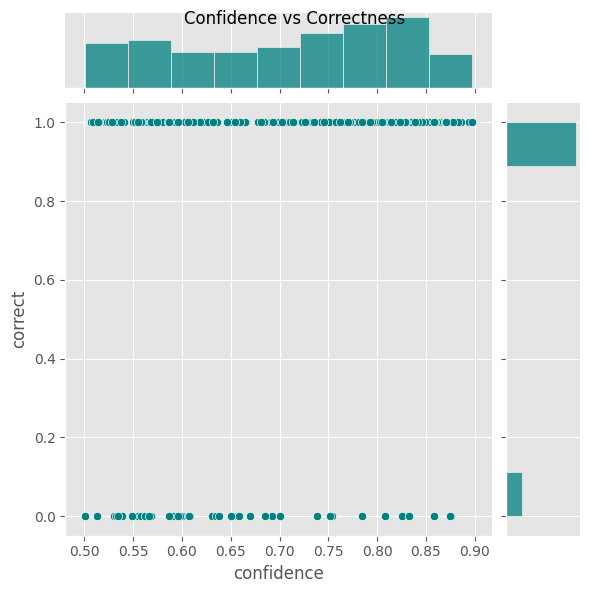

C:\Users\uzair\AppData\Local\Temp\ipykernel_3768\962273183.py:30: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df["predicted_label"] == "real"]["confidence"], label="Predicted Real", shade=True)
C:\Users\uzair\AppData\Local\Temp\ipykernel_3768\962273183.py:31: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df["predicted_label"] == "fake"]["confidence"], label="Predicted Fake", shade=True)


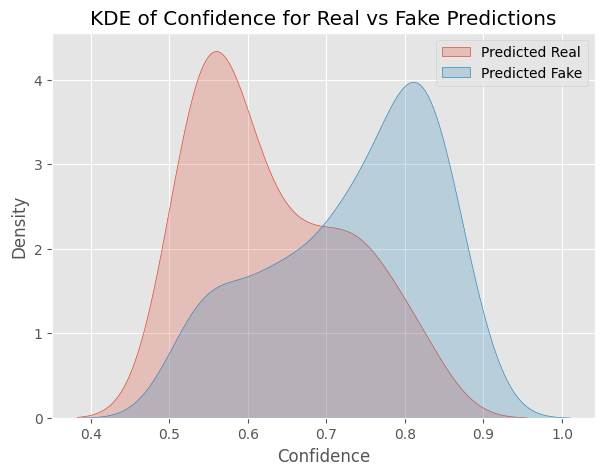

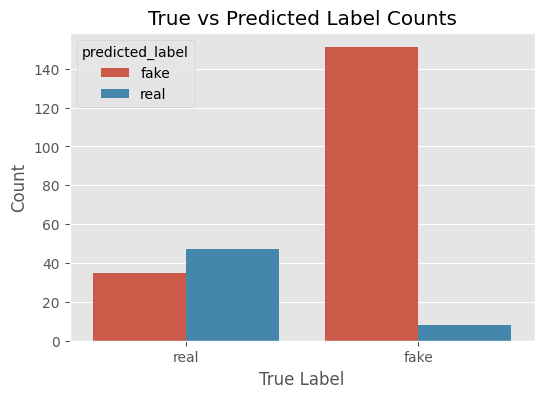

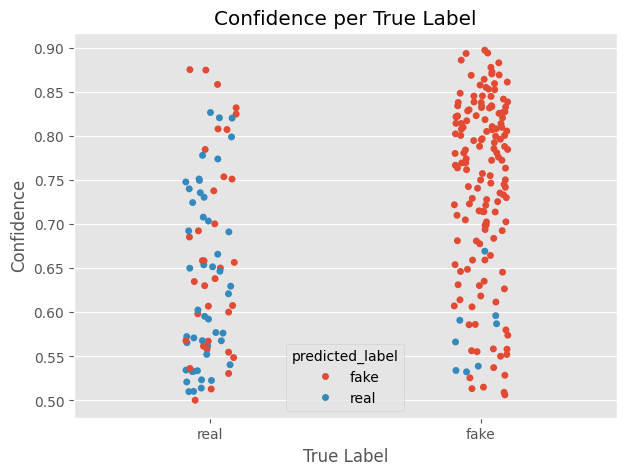

C:\Users\uzair\AppData\Local\Temp\ipykernel_3768\962273183.py:55: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x="predicted_label", y="confidence", data=df, ci="sd", palette="coolwarm")
C:\Users\uzair\AppData\Local\Temp\ipykernel_3768\962273183.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="predicted_label", y="confidence", data=df, ci="sd", palette="coolwarm")


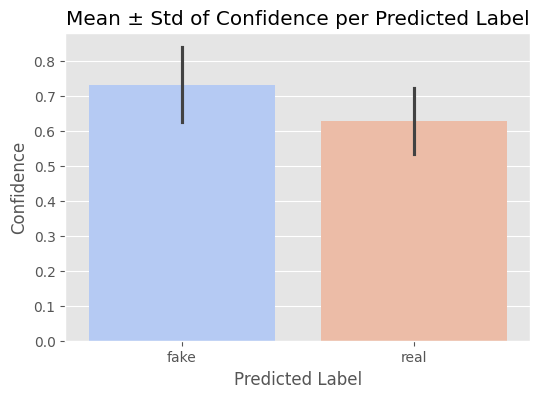

C:\Users\uzair\AppData\Local\Temp\ipykernel_3768\962273183.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  accuracy_by_conf = df.groupby("confidence_bucket")["correct"].mean()


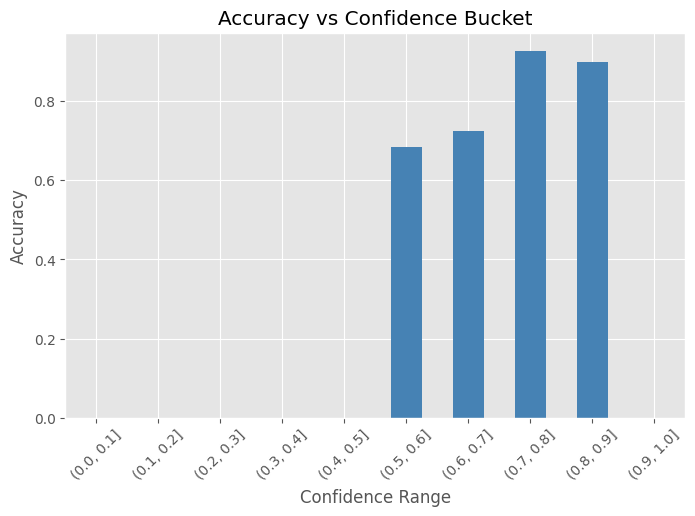

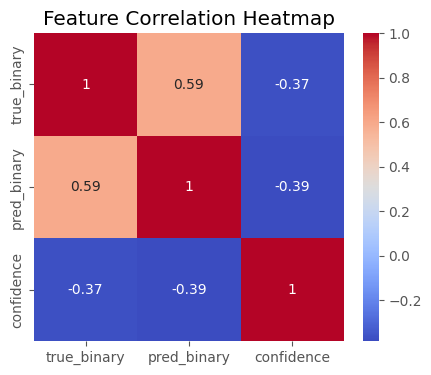

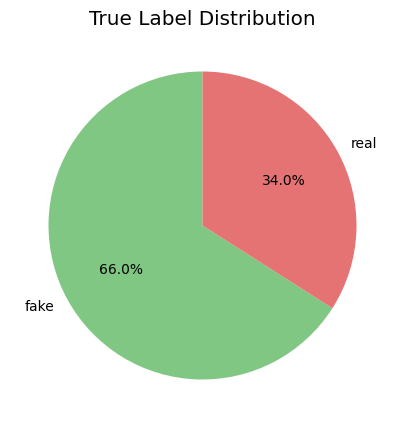

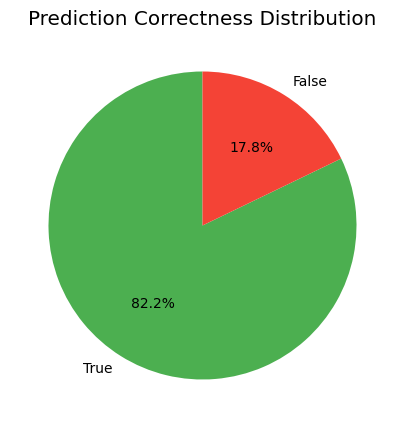

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# Load data
df = pd.read_csv("val_video_predictions.csv")
df["correct"] = df["true_label"] == df["predicted_label"]
df["true_binary"] = df["true_label"].map({"real": 1, "fake": 0})
df["pred_binary"] = df["predicted_label"].map({"real": 1, "fake": 0})

plt.style.use("ggplot")

# 1️⃣1️⃣ Confidence Distribution (Separated by True Label)
plt.figure(figsize=(7, 5))
sns.histplot(data=df, x="confidence", hue="true_label", bins=20, kde=True)
plt.title("Confidence Distribution by True Label")
plt.xlabel("Confidence")
plt.ylabel("Count")
plt.show()

# 1️⃣2️⃣ Joint Plot — Confidence vs Correctness
sns.jointplot(data=df, x="confidence", y="correct", kind="scatter", color="teal")
plt.suptitle("Confidence vs Correctness")
plt.show()

# 1️⃣3️⃣ KDE Plot for Real vs Fake Predictions
plt.figure(figsize=(7, 5))
sns.kdeplot(df[df["predicted_label"] == "real"]["confidence"], label="Predicted Real", shade=True)
sns.kdeplot(df[df["predicted_label"] == "fake"]["confidence"], label="Predicted Fake", shade=True)
plt.title("KDE of Confidence for Real vs Fake Predictions")
plt.xlabel("Confidence")
plt.legend()
plt.show()

# 1️⃣4️⃣ Countplot: True vs Predicted Comparison
plt.figure(figsize=(6, 4))
sns.countplot(x="true_label", hue="predicted_label", data=df)
plt.title("True vs Predicted Label Counts")
plt.xlabel("True Label")
plt.ylabel("Count")
plt.show()

# 1️⃣5️⃣ Confidence Strip Plot per True Label
plt.figure(figsize=(7, 5))
sns.stripplot(x="true_label", y="confidence", hue="predicted_label", data=df, jitter=True)
plt.title("Confidence per True Label")
plt.xlabel("True Label")
plt.ylabel("Confidence")
plt.show()

# 1️⃣6️⃣ Confidence Error Bars (Mean ± Std per Predicted Label)
plt.figure(figsize=(6, 4))
sns.barplot(x="predicted_label", y="confidence", data=df, ci="sd", palette="coolwarm")
plt.title("Mean ± Std of Confidence per Predicted Label")
plt.xlabel("Predicted Label")
plt.ylabel("Confidence")
plt.show()

# 1️⃣7️⃣ Percentage Correct by Confidence Buckets
df["confidence_bucket"] = pd.cut(df["confidence"], bins=np.arange(0, 1.1, 0.1))
accuracy_by_conf = df.groupby("confidence_bucket")["correct"].mean()
plt.figure(figsize=(8, 5))
accuracy_by_conf.plot(kind='bar', color='steelblue')
plt.title("Accuracy vs Confidence Bucket")
plt.xlabel("Confidence Range")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()

# 1️⃣8️⃣ Heatmap — Correlation Between Numeric Columns
plt.figure(figsize=(5, 4))
sns.heatmap(df[["true_binary", "pred_binary", "confidence"]].corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

# 1️⃣9️⃣ Pie Chart — Distribution of True Labels
plt.figure(figsize=(5, 5))
df["true_label"].value_counts().plot.pie(autopct="%1.1f%%", startangle=90, colors=["#81c784", "#e57373"])
plt.title("True Label Distribution")
plt.ylabel("")
plt.show()

# 2️⃣0️⃣ Pie Chart — Correct vs Incorrect Predictions
plt.figure(figsize=(5, 5))
df["correct"].value_counts().plot.pie(autopct="%1.1f%%", startangle=90, colors=["#4caf50", "#f44336"])
plt.title("Prediction Correctness Distribution")
plt.ylabel("")
plt.show()
